## Customer Segmentation

### Objective

Customer Segmentation is the process of grouping users with similar behavioral patterns into meaningful clusters.

The primary objectives of this notebook are:

- Analyze customer behavior patterns
- Identify distinct customer groups
- Build customer segments using machine learning
- Enable targeted recommendations
- Support personalization strategies

This notebook utilizes K-Means Clustering to create behavioral customer segments based on engineered user features.

The generated customer segments will be used by the Recommendation Engine and Personalization Engine in subsequent stages of the project.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Step 1: Load Engineered Features

Load customer-level behavioral features generated during the Feature Engineering phase.

In [2]:
import os

print(os.getcwd())

d:\PROJECTS\RecommendIQ\notebooks


In [3]:
customer_features = pd.read_csv(
    "../data/features/customer_features.csv"
)

customer_features.head()

,visitorid,total_interactions,total_views,total_cart,total_transactions,unique_items,avg_interaction_strength,recency_days
0,0,3,3.0,0.0,0.0,3,1.0,6
1,1,1,1.0,0.0,0.0,1,1.0,35
2,2,8,8.0,0.0,0.0,4,1.0,41
3,3,1,1.0,0.0,0.0,1,1.0,47
4,4,1,1.0,0.0,0.0,1,1.0,2


In [4]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407580 entries, 0 to 1407579
Data columns (total 8 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   visitorid                 1407580 non-null  int64  
 1   total_interactions        1407580 non-null  int64  
 2   total_views               1407580 non-null  float64
 3   total_cart                1407580 non-null  float64
 4   total_transactions        1407580 non-null  float64
 5   unique_items              1407580 non-null  int64  
 6   avg_interaction_strength  1407580 non-null  float64
 7   recency_days              1407580 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 85.9 MB


In [5]:
#descriptive stats
customer_features.describe()

,visitorid,total_interactions,total_views,total_cart,total_transactions,unique_items,avg_interaction_strength,recency_days
count,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06
mean,7.037895e+05,1.957715e+00,1.892765e+00,4.899615e-02,1.595433e-02,1.524019e+00,1.025549e+00,6.790163e+01
std,4.063335e+05,1.257981e+01,1.099361e+01,1.163089e+00,8.260909e-01,7.143724e+00,1.833565e-01,3.916107e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,3.518948e+05,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.500000e+01
50%,7.037895e+05,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,6.700000e+01
75%,1.055684e+06,2.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.020000e+02
max,1.407579e+06,7.757000e+03,6.479000e+03,7.190000e+02,5.590000e+02,3.814000e+03,5.000000e+00,1.370000e+02


In [6]:
customer_features.shape

(1407580, 8)

In [7]:
#Missing Value Validation
customer_features.isnull().sum()

visitorid                   0
total_interactions          0
total_views                 0
total_cart                  0
total_transactions          0
unique_items                0
avg_interaction_strength    0
recency_days                0
dtype: int64

## Log transformation

In [8]:
import numpy as np

columns_to_transform = [
    "total_interactions",
    "total_views",
    "total_cart",
    "total_transactions"
]

for col in columns_to_transform:
    if col in customer_features.columns:
        customer_features[col] = np.log1p(customer_features[col])
        print(f"✅ Transformed: {col}")
    else:
        print(f"⚠️ Column not found: {col}")

✅ Transformed: total_interactions
✅ Transformed: total_views
✅ Transformed: total_cart
✅ Transformed: total_transactions


The customer behavior features were highly right-skewed, with a small number of power users generating thousands of interactions while most users had only one or two interactions. To reduce the influence of outliers on K-Means clustering, I applied a log transformation before standardization and clustering

## Feature Selection

Select numerical behavioral features for clustering

In [9]:
X = customer_features.drop(
    columns=["visitorid"]
)

## Feature Scaling

Standardization ensures that features with larger magnitudes do not dominate clustering.

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Elbow Method

Determine the optimal number of clusters.

In [11]:
inertia = [] #dist from centre to all data points

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

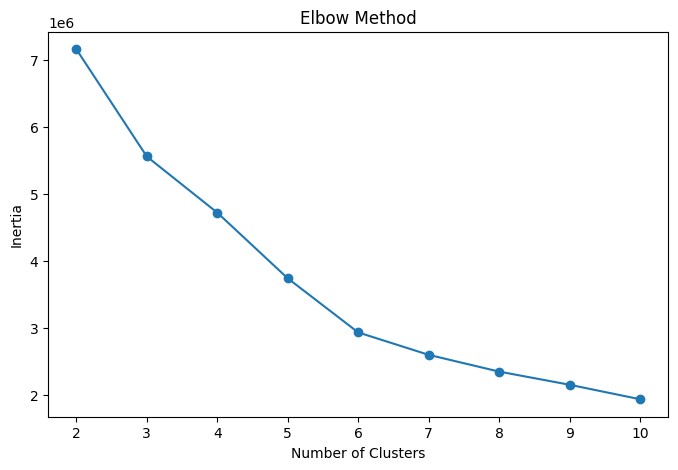

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values, #x-axis
    inertia,#y-axis
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [13]:
feature_columns = [
    "total_interactions",
    "total_views",
    "total_cart",
    "total_transactions",
    "unique_items",
    "avg_interaction_strength",
    "recency_days"
]

In [14]:
customer_features.columns

Index(['visitorid', 'total_interactions', 'total_views', 'total_cart',
       'total_transactions', 'unique_items', 'avg_interaction_strength',
       'recency_days'],
      dtype='object')

## Silhouette Analysis

Evaluate clustering quality for different values of K.

In [15]:
sample_df = customer_features.head(10000)

X_sample = scaler.fit_transform(
    sample_df[feature_columns]
)

In [16]:
scores = []

for k in range(5,6,7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_sample)

    score = silhouette_score(
        X_sample,
        labels
    )

    scores.append(score)

    print(
        f"K={k}, Silhouette Score={score:.4f}"
    )

K=5, Silhouette Score=0.4579


In [17]:
#train final model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

customer_features["cluster"] = kmeans.fit_predict(X_scaled)

In [18]:
#cluster distribution
customer_features["cluster"].value_counts()

cluster
0    637136
2    560965
3    179970
1     29454
4        55
Name: count, dtype: int64

In [19]:
customer_features[feature_columns].describe()

,total_interactions,total_views,total_cart,total_transactions,unique_items,avg_interaction_strength,recency_days
count,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06
mean,9.060852e-01,8.957658e-01,2.317401e-02,7.060279e-03,1.524019e+00,1.025549e+00,6.790163e+01
std,4.278975e-01,4.176706e-01,1.543296e-01,8.538455e-02,7.143724e+00,1.833565e-01,3.916107e+01
min,6.931472e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,6.931472e-01,6.931472e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.500000e+01
50%,6.931472e-01,6.931472e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,6.700000e+01
75%,1.098612e+00,1.098612e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.020000e+02
max,8.956480e+00,8.776476e+00,6.579251e+00,6.327937e+00,3.814000e+03,5.000000e+00,1.370000e+02


In [20]:
#cluster profiling 
cluster_profile = (
    customer_features
    .groupby("cluster")
    .mean()
)

cluster_profile

,visitorid,total_interactions,total_views,total_cart,total_transactions,unique_items,avg_interaction_strength,recency_days
cluster,,,,,,,,
0,703837.024831,0.760861,0.760861,0.000000,0.000000,1.102400,1.000000,36.902922
1,702667.345250,1.723855,1.278030,0.879450,0.328077,4.112413,2.116988,65.016229
2,703939.202849,0.760161,0.760161,0.000000,0.000000,1.096325,1.000000,104.142207
3,703380.696394,1.739320,1.731612,0.036161,0.000478,3.657421,1.016916,65.161505
4,564998.436364,7.131541,7.008517,3.783522,3.432316,880.854545,1.322300,46.581818


In [21]:
cluster_profile = cluster_profile.drop('visitorid',axis=1)

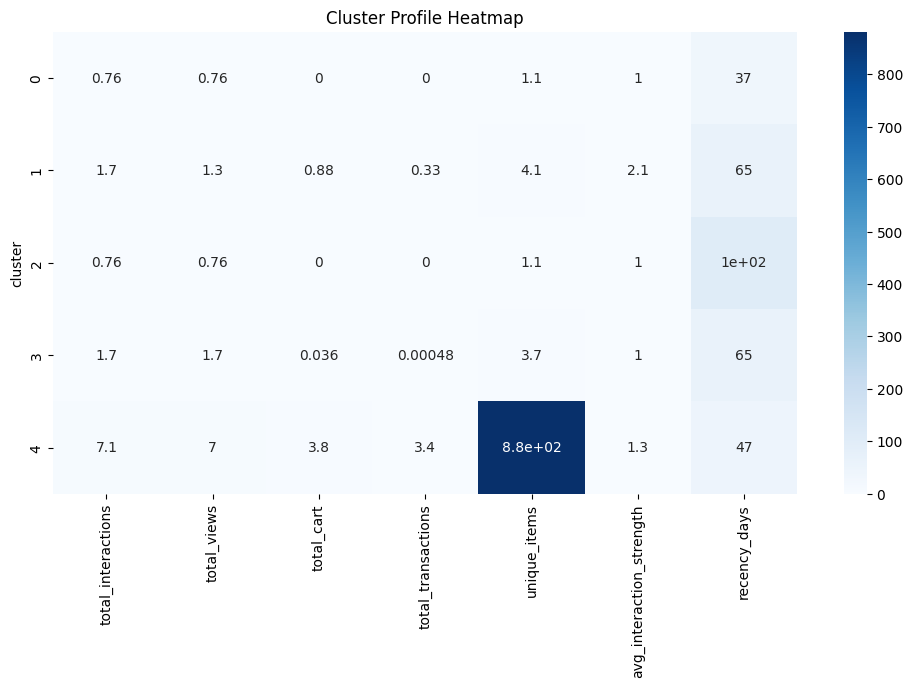

In [22]:
#heatmap
import seaborn as sns
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="Blues"
)

plt.title(
    "Cluster Profile Heatmap"
)

plt.show()

## Assign Segment Names

In [23]:
cluster_names = {
    0: "Browsers",
    1: "Inactive",
    2: "Regular Users",
    3: "Buyers",
    4: "Cart Users"
}


customer_features["segment"] = (
    customer_features["cluster"]
    .map(cluster_names)
)

In [24]:
customer_features.head()

,visitorid,total_interactions,total_views,total_cart,total_transactions,unique_items,avg_interaction_strength,recency_days,cluster,segment
0,0,1.386294,1.386294,0.0,0.0,3,1.0,6,3,Buyers
1,1,0.693147,0.693147,0.0,0.0,1,1.0,35,0,Browsers
2,2,2.197225,2.197225,0.0,0.0,4,1.0,41,3,Buyers
3,3,0.693147,0.693147,0.0,0.0,1,1.0,47,0,Browsers
4,4,0.693147,0.693147,0.0,0.0,1,1.0,2,0,Browsers


## Segment Distribution

In [25]:
customer_features["segment"].value_counts()

segment
Browsers         637136
Regular Users    560965
Buyers           179970
Inactive          29454
Cart Users           55
Name: count, dtype: int64

In [26]:
#Segment Summary
customer_features.groupby(
    "segment"
).mean()

,visitorid,total_interactions,total_views,total_cart,total_transactions,unique_items,avg_interaction_strength,recency_days,cluster
segment,,,,,,,,,
Browsers,703837.024831,0.760861,0.760861,0.000000,0.000000,1.102400,1.000000,36.902922,0.0
Buyers,703380.696394,1.739320,1.731612,0.036161,0.000478,3.657421,1.016916,65.161505,3.0
Cart Users,564998.436364,7.131541,7.008517,3.783522,3.432316,880.854545,1.322300,46.581818,4.0
Inactive,702667.345250,1.723855,1.278030,0.879450,0.328077,4.112413,2.116988,65.016229,1.0
Regular Users,703939.202849,0.760161,0.760161,0.000000,0.000000,1.096325,1.000000,104.142207,2.0


## Saving Segmentation Output

In [27]:
customer_features.to_csv(
    "../data/features/customer_segments.csv",
    index=False
)

## Pipeline

In [28]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [29]:
segmentation_pipeline = Pipeline(
    [   #step1 : log transformation
        (
            "log_transform",
            FunctionTransformer(
                np.log1p,
                validate=False
            )
        ),
         #step2 : scaling
        (
            "scaler",
            StandardScaler()
        ),
        #step3 : clustering
        (
            "kmeans",
            KMeans(
                n_clusters=5,
                random_state=42,
                n_init=10
            )
        )
    ]
)

In [30]:
from sklearn import set_config

set_config(display="diagram")

segmentation_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('log_transform', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func.

## Training Pipeline

In [31]:
customer_features["cluster"] = (
    segmentation_pipeline.fit_predict(
        customer_features[feature_columns]
    )
)

In [32]:
print(segmentation_pipeline)

Pipeline(steps=[('log_transform', FunctionTransformer(func=<ufunc 'log1p'>)),
                ('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=5, n_init=10, random_state=42))])


## Save Pipeline

In [33]:
import joblib

joblib.dump(
    segmentation_pipeline,
    "../artifacts/segmentation_pipeline.pkl"
)

['../artifacts/segmentation_pipeline.pkl']

Conclusion
In this notebook, customer behavioral features were standardized and grouped into meaningful segments using K-Means clustering.

Completed Tasks:

Loaded engineered customer features from csv
Standardized numerical variables
Determined the optimal number of clusters
Applied K-Means clustering
Profiled customer groups
Assigned business-friendly segment labels
Saved customer segmentation results
Generated Output:

customer_segments.csv
segmentation_pipeline.pkl
Business Impact:

Customer segmentation enables targeted marketing, personalized recommendations, and customer profiling.